
# 04 — Signal Digger Checklist (robust)

This notebook provides a practical checklist for evaluating and validating trading signals before using them in backtests or models. It helps you explore the data behind each signal, check its structure and coverage, and run quick diagnostics on performance and correlations.  

Use it as a guide to ensure your signals are properly cleaned, aligned, and statistically sound before moving forward with deeper factor analysis or portfolio construction.

**Outputs**
- `model_ready.csv` (final curated features + `target`)
- `final_features.json` (exact column list)
- `factor_scores.csv`, `regime_ic.csv`, `feature_clusters.json`



## Setup and Configuration

In [80]:
import os
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV, Ridge
from typing import List, Dict, NamedTuple
from numpy.random import default_rng

In [66]:
# ==== Paths (EDIT these) ====
ROOT = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory"
FEATURES_CSV = fr"{ROOT}\outputs\features\selected_features.csv"
TRAIN_CSV = fr"{ROOT}\data\processed\sp500.csv"
TEST_CSV = fr"{ROOT}\data\test.csv"
TARGET_CSV = fr"{ROOT}\data\factor_plus\forward_returns.csv"
SP500_CSV = fr"{ROOT}\data\processed\SP500.csv"

# ==== Outputs ====
OUT_DIR = fr"{ROOT}\outputs\signal_digger"
MODEL_READY = os.path.join(OUT_DIR, "model_ready.csv")
FACTOR_SCORES_CSV = os.path.join(OUT_DIR, "factor_scores.csv")
REGIME_IC_CSV = os.path.join(OUT_DIR, "regime_ic.csv")
CLUSTERS_JSON = os.path.join(OUT_DIR, "feature_clusters.json")
FINAL_FEATURES_JSON = os.path.join(OUT_DIR, "final_features.json")

# ==== Knobs ====
ROLLING_WINDOW = 63
MAX_FEATURES = 40
CORR_THRESHOLD = 0.85
N_PLOT = 6
N_BOOT = 100
SAMPLE_FRAC = 0.75
LASSO_PROB_TH = 0.50
NAN_COL_THRESH = 0.50
WARMUP_MIN = 60
WARMUP_MAX_CAP = 180

os.makedirs(OUT_DIR, exist_ok=True)
print(f"✅ Outputs directory: {OUT_DIR}")

✅ Outputs directory: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger


## Utility Classes and Functions

In [67]:
class FactorScore(NamedTuple):
    """Container for factor stability metrics"""
    feature: str
    mean_ic: float
    std_ic: float
    ir: float
    mean_abs_ic: float
    coverage: float
    t_stat: float
    p_value: float

class FactorLibrary:
    """Core analytics for signal evaluation"""
    
    @staticmethod
    def compute_ic(factor: pd.Series, returns: pd.Series) -> float:
        """Compute Information Coefficient (Spearman correlation)"""
        valid = pd.concat([factor, returns], axis=1).dropna()
        if len(valid) < 10:
            return np.nan
        return stats.spearmanr(valid.iloc[:, 0], valid.iloc[:, 1])[0]
    
    @staticmethod
    def rolling_ic(factor: pd.Series, returns: pd.Series, window: int = 63) -> pd.Series:
        """Calculate rolling IC over time"""
        df = pd.concat([factor, returns], axis=1).dropna()
        if len(df) < window:
            return pd.Series(dtype=float)
        
        ics = []
        for i in range(window, len(df) + 1):
            chunk = df.iloc[i-window:i]
            ic = stats.spearmanr(chunk.iloc[:, 0], chunk.iloc[:, 1])[0]
            ics.append(ic)
        
        return pd.Series(ics, index=df.index[window-1:])
    
    @staticmethod
    def compute_stability_scores(X: pd.DataFrame, y: pd.Series, 
                                window: int = 63) -> List[FactorScore]:
        """Compute comprehensive stability metrics for all features"""
        scores = []
        
        for col in X.columns:
            factor = X[col]
            
            # Rolling IC
            ic_series = FactorLibrary.rolling_ic(factor, y, window)
            
            if len(ic_series) == 0 or ic_series.isna().all():
                continue
            
            mean_ic = ic_series.mean()
            std_ic = ic_series.std()
            ir = mean_ic / std_ic if std_ic > 0 else 0
            mean_abs_ic = ic_series.abs().mean()
            
            # Coverage
            coverage = 1 - (factor.isna().sum() / len(factor))
            
            # Statistical significance
            t_stat = mean_ic / (std_ic / np.sqrt(len(ic_series))) if std_ic > 0 else 0
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), len(ic_series) - 1))
            
            scores.append(FactorScore(
                feature=col,
                mean_ic=mean_ic,
                std_ic=std_ic,
                ir=ir,
                mean_abs_ic=mean_abs_ic,
                coverage=coverage,
                t_stat=t_stat,
                p_value=p_value
            ))
        
        # Sort by Information Ratio
        return sorted(scores, key=lambda x: abs(x.ir), reverse=True)
    
    @staticmethod
    def corr_cluster(X: pd.DataFrame, threshold: float = 0.85):
        """Cluster features by correlation and return representatives"""
        corr_matrix = X.corr().abs()
        linkage_matrix = linkage(1 - corr_matrix, method='average')
        clusters_labels = fcluster(linkage_matrix, 1 - threshold, criterion='distance')
        
        # Group features by cluster
        clusters = {}
        for i, label in enumerate(clusters_labels):
            if label not in clusters:
                clusters[label] = []
            clusters[label].append(X.columns[i])
        
        # Select representative from each cluster (highest mean correlation)
        representatives = []
        for cluster_id, members in clusters.items():
            if len(members) == 1:
                representatives.append(members[0])
            else:
                # Pick feature with highest average correlation within cluster
                cluster_corr = corr_matrix.loc[members, members]
                mean_corrs = cluster_corr.mean(axis=1)
                representatives.append(mean_corrs.idxmax())
        
        return clusters, representatives
    
    @staticmethod
    def realized_vol(returns: pd.Series, span: int = 30) -> pd.Series:
        """Calculate realized volatility using exponential moving average"""
        return returns.ewm(span=span).std()
    
    @staticmethod
    def regime_labels(volatility: pd.Series, n_regimes: int = 3) -> pd.Series:
        """Label volatility regimes (Low, Medium, High)"""
        quantiles = volatility.quantile([0.33, 0.67])
        
        def label_regime(vol):
            if pd.isna(vol):
                return np.nan
            if vol <= quantiles.iloc[0]:
                return 'Low'
            elif vol <= quantiles.iloc[1]:
                return 'Medium'
            else:
                return 'High'
        
        return volatility.apply(label_regime)
    
    @staticmethod
    def regime_ic_table(X: pd.DataFrame, y: pd.Series, regimes: pd.Series, 
                       window: int = 63) -> pd.DataFrame:
        """Calculate IC for each feature across different market regimes"""
        regime_ics = {}
        
        for regime in ['Low', 'Medium', 'High']:
            regime_mask = (regimes == regime)
            regime_ics[regime] = []
            
            for col in X.columns:
                # Calculate IC only for this regime
                factor_regime = X.loc[regime_mask, col]
                returns_regime = y.loc[regime_mask]
                
                if len(factor_regime) < 20:  # Need minimum samples
                    regime_ics[regime].append(np.nan)
                    continue
                
                ic_series = FactorLibrary.rolling_ic(factor_regime, returns_regime, window)
                mean_ic = ic_series.mean() if len(ic_series) > 0 else np.nan
                regime_ics[regime].append(mean_ic)
        
        df = pd.DataFrame(regime_ics, index=X.columns)
        return df
    
fl = FactorLibrary()

In [68]:
def clean_data(df: pd.DataFrame, nan_threshold: float = 0.5) -> pd.DataFrame:
    """Remove columns with too many NaNs and forward-fill remaining"""
    valid_cols = df.columns[df.isna().mean() < nan_threshold]
    df_clean = df[valid_cols].copy()
    df_clean = df_clean.fillna(method='ffill', limit=5)
    return df_clean

def remove_correlated_features(X: pd.DataFrame, threshold: float = 0.85) -> List[str]:
    """Remove highly correlated features, keeping the one with better coverage"""
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = set()
    for col in upper.columns:
        correlated = upper[col][upper[col] > threshold].index.tolist()
        if correlated:
            coverages = {c: 1 - X[c].isna().mean() for c in [col] + correlated}
            best = max(coverages.items(), key=lambda x: x[1])[0]
            to_drop.update([c for c in [col] + correlated if c != best])
    
    return [c for c in X.columns if c not in to_drop]

def stability_based_selection(X: pd.DataFrame, y: pd.Series, 
                             n_boot: int = 100, sample_frac: float = 0.75,
                             threshold: float = 0.5) -> List[str]:
    """Select features based on bootstrap stability"""
    n_samples = int(len(X) * sample_frac)
    feature_counts = {col: 0 for col in X.columns}
    
    for _ in range(n_boot):
        idx = np.random.choice(len(X), size=n_samples, replace=True)
        X_boot = X.iloc[idx]
        y_boot = y.iloc[idx]
        
        try:
            lasso = LassoCV(cv=5, random_state=42, max_iter=1000)
            lasso.fit(X_boot.fillna(0), y_boot)
            
            for i, col in enumerate(X.columns):
                if abs(lasso.coef_[i]) > 1e-10:
                    feature_counts[col] += 1
        except:
            continue
    
    stable_features = [col for col, count in feature_counts.items() 
                      if count / n_boot >= threshold]
    
    return stable_features

def cluster_features(X: pd.DataFrame, n_clusters: int = 10) -> Dict:
    """Hierarchical clustering of features"""
    corr = X.corr().fillna(0)
    linkage_matrix = linkage(corr, method='ward')
    clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    
    cluster_dict = {}
    for i, col in enumerate(X.columns):
        cluster_id = int(clusters[i])
        if cluster_id not in cluster_dict:
            cluster_dict[cluster_id] = []
        cluster_dict[cluster_id].append(col)
    
    return cluster_dict

## Step 1: Load and Prepare Data

In [69]:
print("="*80)
print("STEP 1: LOAD AND PREPARE DATA")
print("="*80)

# Load features
if os.path.exists(FEATURES_CSV):
    features_df = pd.read_csv(FEATURES_CSV, parse_dates=['date'])
    print(f"✅ Loaded features: {features_df.shape}")
else:
    print(f"❌ Features file not found: {FEATURES_CSV}")
    features_df = None

# Load or create target
if os.path.exists(TARGET_CSV):
    target_df = pd.read_csv(TARGET_CSV, parse_dates=['date'])
    print(f"✅ Loaded target: {target_df.shape}")
else:
    print(f"⚠️  Target not found, creating from {SP500_CSV}")
    sp = pd.read_csv(SP500_CSV, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    
    if "market_forward_excess_returns" in sp.columns:
        sp["forward_returns"] = sp["market_forward_excess_returns"]
    else:
        price_cols = ['close', 'Close', 'price', 'Price', 'adj_close', 'Adj Close']
        price_col = next((c for c in price_cols if c in sp.columns), None)
        
        if price_col:
            sp[price_col] = pd.to_numeric(sp[price_col], errors="coerce")
            sp["forward_returns"] = np.log(sp[price_col].shift(-1) / sp[price_col])
        else:
            raise ValueError("No price column found to compute returns")
    
    target_df = sp[["date", "forward_returns"]].dropna()
    os.makedirs(os.path.dirname(TARGET_CSV), exist_ok=True)
    target_df.to_csv(TARGET_CSV, index=False)
    print(f"✅ Created target: {target_df.shape}")

# Merge
df = pd.merge(features_df, target_df, on='date', how='inner')
print(f"✅ Merged dataset: {df.shape}")

X = df.drop(['date', 'forward_returns'], axis=1, errors='ignore')
y = df['forward_returns']
date_index = df['date']

print(f"\n📊 Features: {X.shape[1]}")
print(f"📊 Samples: {len(y)}")
print(f"📊 Date range: {date_index.min()} to {date_index.max()}")

STEP 1: LOAD AND PREPARE DATA
✅ Loaded features: (8990, 22)
✅ Loaded target: (8990, 2)
✅ Merged dataset: (8990, 23)

📊 Features: 21
📊 Samples: 8990
📊 Date range: 1990-01-01 00:00:00 to 2014-08-12 00:00:00


## Step 2: Data Cleaning

In [70]:
print("="*80)
print("STEP 2: INITIAL DATA CLEANING")
print("="*80)

print(f"Before cleaning: {X.shape[1]} features")

# Remove columns with excessive NaNs
X_clean = clean_data(X, nan_threshold=NAN_COL_THRESH)
print(f"After NaN filtering: {X_clean.shape[1]} features")

# Remove highly correlated features (basic deduplication)
selected_cols = remove_correlated_features(X_clean, threshold=CORR_THRESHOLD)
X_clean = X_clean[selected_cols]
print(f"After correlation filtering: {X_clean.shape[1]} features")

STEP 2: INITIAL DATA CLEANING
Before cleaning: 21 features
After NaN filtering: 5 features
After correlation filtering: 5 features


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\3037713162.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method='ffill', limit=5)


## Step 3: Warm-up and Data Preparation

In [71]:
print("="*80)
print("STEP 3: WARM-UP PERIOD HANDLING")
print("="*80)

import re

# Detect maximum window size from feature names
max_win = 0
for c in X_clean.columns:
    for pat in (r"_W(\d+)", r"_T(\d+)"):
        m = re.search(pat, c)
        if m:
            max_win = max(max_win, int(m.group(1)))

DROP_HEAD = max(WARMUP_MIN, max_win)
DROP_HEAD = min(DROP_HEAD, WARMUP_MAX_CAP)
print(f"Detected max window: {max_win}")
print(f"Warm-up rows to drop: {DROP_HEAD}")

# Apply warm-up drop
X_warm = X_clean.iloc[DROP_HEAD:].replace([np.inf, -np.inf], np.nan)
y_warm = y.iloc[DROP_HEAD:].copy()
date_warm = date_index.iloc[DROP_HEAD:].copy()

print(f"Data after warm-up: {X_warm.shape}, y: {len(y_warm)}")

STEP 3: WARM-UP PERIOD HANDLING
Detected max window: 60
Warm-up rows to drop: 60
Data after warm-up: (8930, 5), y: 8930


## Step 4: Compute Factor Scores

In [72]:
print("="*80)
print("STEP 4: COMPUTE FACTOR SCORES")
print("="*80)

scores = fl.compute_stability_scores(X_clean, y, window=ROLLING_WINDOW)
scores_df = pd.DataFrame([s._asdict() for s in scores])
scores_df.to_csv(FACTOR_SCORES_CSV, index=False)
print(f"✅ Saved factor scores: {FACTOR_SCORES_CSV}")

print("\n📊 Top 20 Features by Information Ratio:")
display(scores_df.head(20))

STEP 4: COMPUTE FACTOR SCORES


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1117239461.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = stats.spearmanr(chunk.iloc[:, 0], chunk.iloc[:, 1])[0]


✅ Saved factor scores: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\factor_scores.csv

📊 Top 20 Features by Information Ratio:


,feature,mean_ic,std_ic,ir,mean_abs_ic,coverage,t_stat,p_value
0,ZSCORE_V1_W60,-0.017321,0.112999,-0.153286,0.091541,0.578420,-10.987532,0.000000e+00
1,TECH_ROC_S1_10,0.014773,0.120315,0.122787,0.095438,0.886986,10.921829,0.000000e+00
2,MOM_S1_T20,0.010526,0.110408,0.095333,0.090077,0.885873,8.474493,0.000000e+00
3,ROLL_STD_V1_W60,0.007990,0.108102,0.073912,0.086437,0.881535,6.554071,5.952017e-11
4,market_forward_excess_returns,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000e+00


## Step 5: Visualize Top Features

STEP 5: VISUALIZE TOP FEATURES


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1117239461.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = stats.spearmanr(chunk.iloc[:, 0], chunk.iloc[:, 1])[0]


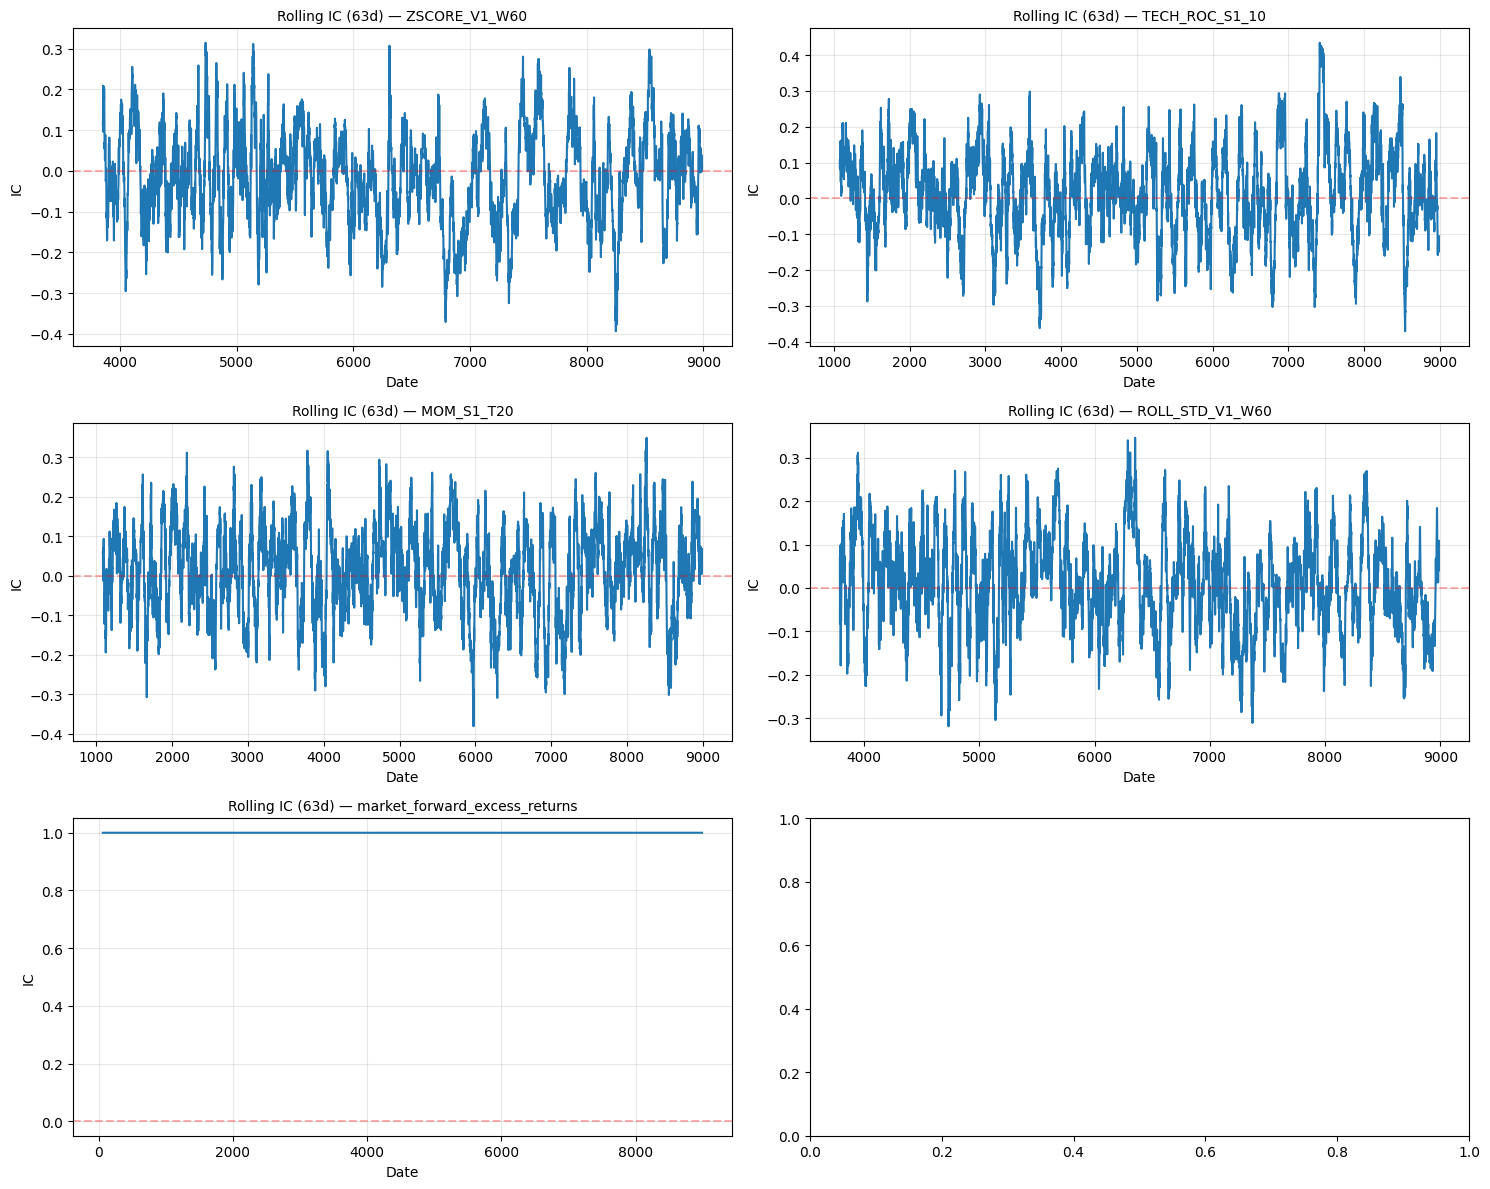

In [73]:
print("="*80)
print("STEP 5: VISUALIZE TOP FEATURES")
print("="*80)

to_plot = [s.feature for s in scores[:N_PLOT]]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, f in enumerate(to_plot):
    if f in X_clean.columns:
        ic_roll = fl.rolling_ic(X_clean[f], y, window=ROLLING_WINDOW)
        axes[i].plot(ic_roll.index, ic_roll.values, linewidth=1.5)
        axes[i].axhline(0, color='red', linestyle='--', alpha=0.3)
        axes[i].set_title(f"Rolling IC ({ROLLING_WINDOW}d) — {f}", fontsize=10)
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("IC")
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'top_features_ic.png'), dpi=150)
plt.show()

# Step 6: Correlation-Based Clustering

In [76]:
print("\n" + "="*80)
print("STEP 6: CORRELATION-BASED CLUSTERING")
print("="*80)

# Build initial pool from top-ranked features
pool = [s.feature for s in scores[:max(100, MAX_FEATURES*3)]]

# Drop nearly all-NaN features
pre_na = X_warm[pool].isna().mean().sort_values(ascending=False)
drop_pre = pre_na[pre_na > 0.95].index.tolist()
if drop_pre:
    print(f"Dropping pre-cluster ~all-NaN: {drop_pre[:10]} …")
    pool = [c for c in pool if c not in drop_pre]

# Cluster by correlation and select representatives
clusters, reps = fl.corr_cluster(
    X_warm[pool].fillna(method="ffill").fillna(method="bfill"), 
    threshold=CORR_THRESHOLD
)

with open(CLUSTERS_JSON, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in clusters.items()}, f, indent=2)

print(f"✅ Saved clusters: {CLUSTERS_JSON}")
print(f"Clusters: {len(clusters)}, Representatives: {len(reps)}")

selected_by_cluster = reps[:max(MAX_FEATURES*2, 30)]
print(f"Initial reps kept: {len(selected_by_cluster)}")


STEP 6: CORRELATION-BASED CLUSTERING
✅ Saved clusters: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\feature_clusters.json
Clusters: 5, Representatives: 5
Initial reps kept: 5


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\2482062834.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_warm[pool].fillna(method="ffill").fillna(method="bfill"),
C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1117239461.py:83: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(1 - corr_matrix, method='average')


## Step 7: Regime Analysis

In [77]:
print("\n" + "="*80)
print("STEP 7: REGIME ANALYSIS")
print("="*80)

# Calculate realized volatility and regime labels
rv = fl.realized_vol(y_warm, span=30)
regimes = fl.regime_labels(rv)

print(f"\nRegime distribution:")
print(regimes.value_counts())

# Calculate IC across regimes
reg_table = fl.regime_ic_table(X_warm[selected_by_cluster], y_warm, regimes, window=ROLLING_WINDOW)
reg_table.to_csv(REGIME_IC_CSV)
print(f"\n✅ Saved: {REGIME_IC_CSV}")

print("\n📊 Top 20 Features by Regime IC:")
print(reg_table.head(20).to_string())

# Keep features that perform well in at least 2 regimes
keep_regime = []
for f in reg_table.index:
    vals = reg_table.loc[f].dropna().values
    if (vals > 0).sum() >= 2:
        keep_regime.append(f)

print(f"\nRegime-kept: {len(keep_regime)}")

candidate_set = keep_regime if len(keep_regime) >= MAX_FEATURES//2 else selected_by_cluster
print(f"Candidate set: {len(candidate_set)}")


STEP 7: REGIME ANALYSIS

Regime distribution:
forward_returns
Medium    3035
Low       2947
High      2947
Name: count, dtype: int64


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1117239461.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = stats.spearmanr(chunk.iloc[:, 0], chunk.iloc[:, 1])[0]
C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1117239461.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = stats.spearmanr(chunk.iloc[:, 0], chunk.iloc[:, 1])[0]
C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1117239461.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = stats.spearmanr(chunk.iloc[:, 0], chunk.iloc[:, 1])[0]



✅ Saved: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\regime_ic.csv

📊 Top 20 Features by Regime IC:
                                    Low    Medium      High
ZSCORE_V1_W60                 -0.038596 -0.019019 -0.008994
TECH_ROC_S1_10                 0.015861  0.000939  0.030350
MOM_S1_T20                    -0.013013 -0.005279  0.032657
ROLL_STD_V1_W60                0.008442  0.027931  0.003287
market_forward_excess_returns  1.000000  1.000000  1.000000

Regime-kept: 3
Candidate set: 5


## Step 8: Prepare Data for Stability Selection

In [78]:
print("\n" + "="*80)
print("STEP 8: PREPARE DATA FOR STABILITY SELECTION")
print("="*80)

# Remove high-NaN columns from candidate set
na_ratio = X_warm[candidate_set].isna().mean().sort_values(ascending=False)
bad_cols = na_ratio[na_ratio > NAN_COL_THRESH].index.tolist()
if bad_cols:
    print(f"Dropping high-NaN columns: {bad_cols[:10]} …")
cand = [c for c in candidate_set if c not in bad_cols]

# Fill and impute
X2_part = X_warm[cand].fillna(method='ffill').fillna(method='bfill')
imp = SimpleImputer(strategy="median")
X2_imp = pd.DataFrame(imp.fit_transform(X2_part), index=X2_part.index, columns=cand)

# Standardize
scaler = StandardScaler()
X2_std = pd.DataFrame(scaler.fit_transform(X2_imp), index=X2_imp.index, columns=cand)

# Widen if too few features
if X2_std.shape[1] < max(10, MAX_FEATURES//2):
    widen = [c for c in selected_by_cluster if c not in cand]
    widen = widen[:max(0, max(10, MAX_FEATURES) - X2_std.shape[1])]
    if widen:
        X2_more = X_warm[widen].fillna(method='ffill').fillna(method='bfill')
        X2_more = pd.DataFrame(imp.fit_transform(X2_more), index=X2_more.index, columns=widen)
        X2_more = pd.DataFrame(scaler.fit_transform(X2_more), index=X2_more.index, columns=widen)
        X2_std = pd.concat([X2_std, X2_more], axis=1)
        cand = list(X2_std.columns)
        print(f"Widened candidate set to: {len(cand)}")

y2 = y_warm.copy()

print(f"Cleaned & standardized matrix: {X2_std.shape}")


STEP 8: PREPARE DATA FOR STABILITY SELECTION
Cleaned & standardized matrix: (8930, 5)


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\3863861470.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X2_part = X_warm[cand].fillna(method='ffill').fillna(method='bfill')


## Step 9: Bootstrap Stability Selection

In [81]:
print("\n" + "="*80)
print("STEP 9: BOOTSTRAP STABILITY SELECTION")
print("="*80)

# Setup alpha grid
if ALPHA_GRID is None:
    alpha_grid = np.logspace(-6, 0, 60)
else:
    alpha_grid = ALPHA_GRID

rng = default_rng(42)

# Lasso stability
print(f"Running {N_BOOT} Lasso bootstrap iterations...")
counts = pd.Series(0.0, index=X2_std.columns)
for b in range(N_BOOT):
    idx = rng.choice(np.arange(len(X2_std)), size=int(len(X2_std) * SAMPLE_FRAC), replace=False)
    m = LassoCV(alphas=alpha_grid, cv=3, random_state=42)
    m.fit(X2_std.iloc[idx], y2.iloc[idx])
    sel = (np.abs(m.coef_) > 1e-8)
    counts.loc[X2_std.columns[sel]] += 1
lasso_probs = counts / N_BOOT

# ElasticNet stability
print(f"Running {N_BOOT//2} ElasticNet bootstrap iterations...")
counts_en = pd.Series(0.0, index=X2_std.columns)
enet = ElasticNetCV(l1_ratio=[0.05, 0.1, 0.2, 0.3, 0.5], alphas=alpha_grid, cv=3, random_state=42)
for b in range(N_BOOT//2):
    idx = rng.choice(np.arange(len(X2_std)), size=int(len(X2_std) * SAMPLE_FRAC), replace=False)
    enet.fit(X2_std.iloc[idx], y2.iloc[idx])
    sel_en = (np.abs(enet.coef_) > 1e-8)
    counts_en.loc[X2_std.columns[sel_en]] += 1
enet_probs = counts_en / (N_BOOT//2)

print(f"\nLasso stable ≥{LASSO_PROB_TH:.0%}: {int((lasso_probs>=LASSO_PROB_TH).sum())}")
print(f"ENet  stable ≥{LASSO_PROB_TH:.0%}: {int((enet_probs>=LASSO_PROB_TH).sum())}")


STEP 9: BOOTSTRAP STABILITY SELECTION
Running 100 Lasso bootstrap iterations...
Running 50 ElasticNet bootstrap iterations...

Lasso stable ≥50%: 1
ENet  stable ≥50%: 3


## Step 10: Permutation Importance

In [82]:
print("\n" + "="*80)
print("STEP 10: PERMUTATION IMPORTANCE")
print("="*80)

# Train Ridge on 80% of data
ridge = Ridge(alpha=1.0).fit(
    X2_std.iloc[:-int(len(X2_std)*0.2)], 
    y2.iloc[:-int(len(X2_std)*0.2)]
)

def sharpe_like(y_true, y_pred):
    pnl = y_true * y_pred
    return float(pnl.mean() / (pnl.std(ddof=0) + 1e-12))

# Validate on last 20%
val_slice = slice(int(len(X2_std)*0.8), None)
base = sharpe_like(y2.iloc[val_slice], ridge.predict(X2_std.iloc[val_slice]))

print(f"Base validation Sharpe: {base:.4f}")

# Permutation importance
perm_drop = {}
for c in X2_std.columns:
    Xp = X2_std.copy()
    Xp.loc[X2_std.index[val_slice], c] = np.random.permutation(
        Xp.loc[X2_std.index[val_slice], c].values
    )
    perm_drop[c] = base - sharpe_like(y2.iloc[val_slice], ridge.predict(Xp.iloc[val_slice]))

perm_keep = [c for c, d in perm_drop.items() if d > 0]
print(f"Features with positive permutation importance: {len(perm_keep)}")


STEP 10: PERMUTATION IMPORTANCE
Base validation Sharpe: 0.4872
Features with positive permutation importance: 4


## Step 11: Compose Final Feature Set

In [83]:
print("\n" + "="*80)
print("STEP 11: COMPOSE FINAL FEATURE SET")
print("="*80)

# Rank candidates by original IC scores
candidates_ranked = [s.feature for s in scores if s.feature in cand]

selected = []
for f in candidates_ranked:
    # Include if: strong permutation importance OR stable in Lasso/ElasticNet
    if (f in perm_keep or 
        lasso_probs.get(f, 0) >= LASSO_PROB_TH or 
        enet_probs.get(f, 0) >= LASSO_PROB_TH):
        selected.append(f)
    if len(selected) >= MAX_FEATURES:
        break

# Fill up to MAX_FEATURES if needed
if len(selected) < MAX_FEATURES:
    for f in candidates_ranked:
        if f not in selected:
            selected.append(f)
        if len(selected) >= MAX_FEATURES:
            break

print(f"Final selected: {len(selected)}")

# Show selection breakdown
n_lasso = sum(1 for f in selected if lasso_probs.get(f, 0) >= LASSO_PROB_TH)
n_enet = sum(1 for f in selected if enet_probs.get(f, 0) >= LASSO_PROB_TH)
n_perm = sum(1 for f in selected if f in perm_keep)

print(f"\nSelection breakdown:")
print(f"  - Lasso stable: {n_lasso}")
print(f"  - ElasticNet stable: {n_enet}")
print(f"  - Positive perm importance: {n_perm}")


STEP 11: COMPOSE FINAL FEATURE SET
Final selected: 5

Selection breakdown:
  - Lasso stable: 1
  - ElasticNet stable: 3
  - Positive perm importance: 4


## Step 12: Export Model-Ready Dataset

In [84]:
print("\n" + "="*80)
print("STEP 12: EXPORT MODEL-READY DATASET")
print("="*80)

# Prepare final features - use the warm-up adjusted data
imp2 = SimpleImputer(strategy="median")
X_final = X_warm[selected].copy().fillna(method='ffill').fillna(method='bfill')
X_final = pd.DataFrame(
    imp2.fit_transform(X_final), 
    index=X_final.index, 
    columns=X_final.columns
)

# Combine with target
df_model = pd.concat([X_final, y_warm.rename("target")], axis=1).dropna(subset=["target"])

# Save
df_model.to_csv(MODEL_READY, index=True)
with open(FINAL_FEATURES_JSON, "w", encoding="utf-8") as f:
    json.dump(selected, f, indent=2)

print(f"✅ Saved model_ready: {MODEL_READY}")
print(f"✅ Saved final_features.json: {FINAL_FEATURES_JSON}")
print(f"\nModel-ready dataset shape: {df_model.shape}")
print(f"\nFirst few rows:")
print(df_model.head().to_string())
print(f"\nSummary statistics:")
print(df_model.describe().to_string())


STEP 12: EXPORT MODEL-READY DATASET
✅ Saved model_ready: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\model_ready.csv
✅ Saved final_features.json: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\final_features.json

Model-ready dataset shape: (8930, 6)

First few rows:
    ZSCORE_V1_W60  TECH_ROC_S1_10  MOM_S1_T20  ROLL_STD_V1_W60  market_forward_excess_returns    target
60       7.616867        0.040034   -0.119023              0.0                      -0.004015 -0.004015
61       7.616867        0.040034   -0.119023              0.0                      -0.002990 -0.002990
62       7.616867        0.040034   -0.119023              0.0                      -0.004148 -0.004148
63       7.616867        0.040034   -0.119023              0.0                       0.014147  0.014147
64       7.616867        0.040034   -0.119023              0.0                      -0.007

C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_7512\1167817665.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_final = X_warm[selected].copy().fillna(method='ffill').fillna(method='bfill')
